# Forward model for DAS recorded amplitude 

In this notebook we use the travel time grids created in the previous on to forward model the amplitude recorded across a DAS array, from a point source, acounting for geometrical spreading.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pykonal 
from pykonal.transformations import geo2sph, sph2geo
import pandas as pd
from tqdm import tqdm
import glob
import re

import sys
import os

sys.path.append(os.path.abspath("../src"))
from fct_DAS_sensitivity import *


## 1) Prepare each chanel information

Populate the CSV containing the channel location with the azimuth and the dip of the fiber <br>
The headers in the CSV file must be 'lat','lon' and 'depth' <br>

In [2]:
### path to station info ###
file_name = 'BHS_DASH'
station_info_path = os.path.abspath("../Data/DAS_arrays/Brady_Hot_springs/{}.csv".format(file_name))
df = pd.read_csv(station_info_path, sep = ',', index_col =0)
df = compute_azimuth_dip(df)
df.head()

,lat,lon,Elevation,depth_,depth,azimuth,dip
Distance,,,,,,,
35,39.799373,-119.011287,1225.881455,-1.225881,-1.250118,7.174915,-0.000049
46,39.799471,-119.011303,1225.796545,-1.225797,-1.250118,7.174178,-0.000049
57,39.799569,-119.011319,1225.711727,-1.225712,-1.250118,7.087563,-0.000049
68,39.799666,-119.011335,1225.628182,-1.225628,-1.250118,342.850985,-0.000046
79,39.799754,-119.011300,1225.717909,-1.225718,-1.250118,324.298368,-0.000049


## 2) Load data from travel time 

Point to the folders with the traveltime grids, but also the output folder. In it will be created a .CSV file containing amplitude informations. This file will be name as your 'file_name'.

In [3]:
# Path to the folder containing the travel time grids
folder = r'C:\Users\liliv\Desktop\DAS_senstivity\test'

# Path to output amplitude file in .csv 
folder_out = r'C:\Users\liliv\Desktop\DAS_senstivity\Amplitude_test'

# Name of the output CSV 
file_name = 'test' 

## 3) Define your source

To define your source you must **locate** it using the class: <br>
* Location(latitude, longitude, depth) # °N, °E, km (sea level = 0, positif going down)

We created 3 classes of source for different applications : <br>
* **Homogeneous** : <br>

e = IsotropicSource(amplitude) <br>
* **Moment tensor** : <br>

e = MomentTensor(xx, yy, zz, xy, xz, yz)  <br>

* **Single force**: <br>

e = SingleForce(N, E, depth) <br><br>
For all these source we only use the far field approximation of the orientation specific amplitude distribution of the energy around the source. 

In [17]:
# Locate your source in space 
loc = Location(39.80950454 , -119.000843 , -1.250118) # lat, lon depth

# Describe the energy inside 
e = MomentTensor(0,0,0, 1, 0,0 )
#Create the source object 
source = SeismicSource(file_name, loc, e)

# Wave type to considerate in computation 
wave_type_list = ['P','SV', 'SH']


You can also plot the radiation pattern to make sure you have set correct parameters. See objecs_overview.ipynb for more plotting option

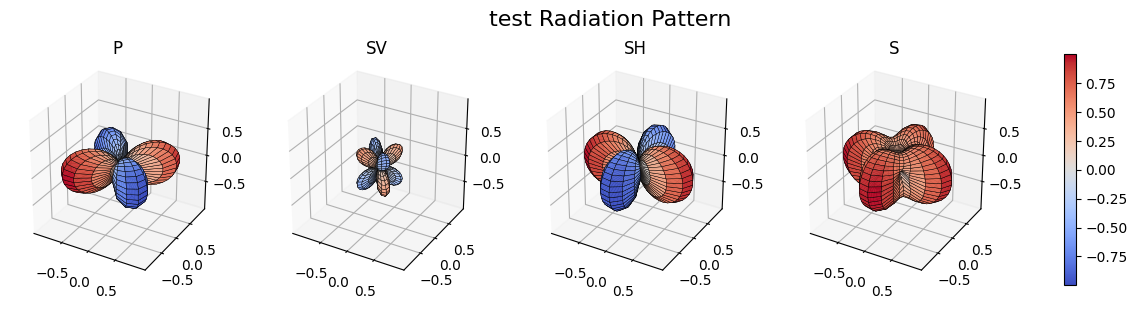

In [18]:
source.plot_radiation_pattern()

## 4) Error estimate

To have some estimate of your uncertunty, you can set an error on the receiver and the source. It will be evenly distributed across dip and azimuth. The error will be obtaine using Monte Carlo approach with 'MC_sample_number' of itteration using the error values as a perturbation. <br>
The minimum distance parameter allows to use a straight ray if the source is too close to the receiver. This solves a probleme for pykonal who makes some weird rays, speed computation as well. 

In [19]:
# MC error hestimate
receiver_error = 3.55
source_error = 0.59
MC_sample_number = 100

# Minimum distance (km)
min_distance = 10.01

## 5) Load model informations from $\delta$ travltime grids and verify source parameters

In [20]:
# Pykonal specific

latitudes = xr.load_dataarray(glob.glob(folder+'//*')[0]).coords['latitude'].values
longitudes = xr.load_dataarray(glob.glob(folder+'//*')[0]).coords['longitude'].values
depths = xr.load_dataarray(glob.glob(folder+'//*')[0]).coords['depth'].values

# node spacing
grid_spacing = (
    np.abs(depths[1] - depths[0]),
    np.deg2rad(np.abs(latitudes[1] - latitudes[0])),
    np.deg2rad(np.abs(longitudes[1] - longitudes[0])),)


# give the shape of your grid, here use the first grid of dataset and extract variable 
model_shape = xr.load_dataarray(glob.glob(folder+'/*')[0]).transpose( 'depth','latitude', 'longitude').values.shape


reference_point = geo2sph((latitudes.max(), longitudes.min(), depths.max()))

# Verify if source is in the model space
source_coord = np.array(geo2sph(source.location.values).squeeze())
max_coord = reference_point + (np.array(grid_spacing)*model_shape)
is_inside = np.all((source_coord >= reference_point) & (source_coord <= max_coord))

if is_inside:
    print('--------------------------------')
    print("Source is within the model space.")
    print('--------------------------------')
else:
    print('----------------------------------------')
    print("ERROR: Source is outside the model space!")
    print('----------------------------------------')
    dimensions = np.array(['depth', 'latitude', 'longitude'])
    for i, (s, mn, mx) in enumerate(zip(source_coord, reference_point, max_coord)):
        if not (mn <= s <= mx):
            print(f"Dimension {dimensions[i]}: {s:.6f} not in [{mn:.6f}, {mx:.6f}]")

--------------------------------
Source is within the model space.
--------------------------------


## 6) create the model space

In [21]:
### Initialize the solver once with constant grid settings ###

solver = pykonal.solver.PointSourceSolver(coord_sys="spherical")
# Set up grid properties
solver.velocity.min_coords = reference_point
solver.velocity.node_intervals = grid_spacing
solver.velocity.npts = model_shape  # Ensure shape matches the travel time grid


# Create DataFrame to hold results 
result_container = pd.DataFrame()

# Create a list with all channel names to load travel times grids one after the other
all_files = glob.glob(folder+'//*')
number_only = [float(number.split('\\')[-1].split('.')[0]) for number in all_files]
number_only = sorted(number_only)

## 7) Run the model

In [22]:
for channel_name in tqdm(number_only):
      #try:
        ttime_path= folder+'\\'+str(channel_name)+'.h5'

        # extract the channel's specific informations 
        das = DASSensor(azimuth=df.loc[int(channel_name), 'azimuth'],
                        dip=df.loc[int(channel_name), 'dip'],
                        longitude = df.loc[int(channel_name), 'lon'],
                        latitude = df.loc[int(channel_name), 'lat'],
                        depth = df.loc[int(channel_name), 'depth'])
        
        # Load the travel time grid and assign it to the solver (check dimensions)
        ttimes = xr.load_dataarray(ttime_path)
        # Ensure the travel time grid is set correctly in the solver
        solver.tt.values = ttimes.transpose('depth', 'latitude', 'longitude').values  # Adjust dimensions if needed
        
        # trace ray 
        end = np.array(geo2sph(source.location.values).squeeze()) 
        d = distance_3d_km(lat1=das.values()[0], lon1=das.values()[1], depth1_km=das.values()[2],lat2=source.location.values[0], lon2=source.location.values[1], depth2_km=source.location.values[2])
        # 1) if source and receiver to close => take a straight ray 
        if d<= min_distance:
                lats = np.linspace(das.values()[0],source.location.values[0], 200 ) # ° latitude (N)
                lons = np.linspace(das.values()[1],source.location.values[1], 200 ) # ° longitude (E)
                depth = np.linspace (das.values()[2],source.location.values[2], 200) # km of depth
                ray = np.array([lats, lons, depth])
                ray = Ray(geo2sph(ray.T))

        # 2) if source revceiver far enough => use ttime to run ray tracing 
        else:
                
                ray_nodes = solver.trace_ray(end)
                # Pykonal returns a ray without the source and receiver node. We add them back in this line 
                # first node is at the DAS and last node at the source
                ray_nodes = np.vstack([np.array(geo2sph(das.values()).squeeze()),ray_nodes, end ])
                ray = Ray(ray_nodes)
                
        tt_source = solver.traveltime.value(end)

        # save ttime value
        result_container.loc[str(channel_name), 'ttime'] = tt_source 
        # get ray length in m
        ray_length = ray.length_spherical()*1000 # in m 

        #ray.plot_views()

        az_ray_DAS, dip_ray_DAS = ray.azimuth_and_dip('DAS', 50)
        az_ray_source, dip_ray_source = ray.azimuth_and_dip('source', 50)

        for wave_type in wave_type_list :

                # use MC sampling to get error on measure 
                MC_Channel_amplitude = np.zeros(MC_sample_number)

                MC_dip_fibre = np.random.normal(loc=dip_ray_DAS, scale=receiver_error/np.sqrt(2), size=MC_sample_number) #3.5/np.sqrt(2)
                MC_ray_azimuth_fibre = np.random.normal(loc=az_ray_DAS, scale=receiver_error/np.sqrt(2), size=MC_sample_number) #3.5/np.sqrt(2)
                
                MC_azimuth_source = np.random.normal(loc=az_ray_source, scale=source_error/np.sqrt(2), size=MC_sample_number) #3.5/np.sqrt(2)
                MC_colatitude_source = np.random.normal(loc=dip_ray_source, scale=source_error/np.sqrt(2), size=MC_sample_number) #3.5/np.sqrt(2)
                
                for MC_sample in range(MC_sample_number):
                
                        if MC_sample != 0:
                        
                                dip_ray_source = MC_colatitude_source[MC_sample]
                                az_ray_source = MC_azimuth_source [MC_sample]
                                
                                az_ray_DAS = MC_ray_azimuth_fibre[MC_sample]
                                dip_ray_DAS = MC_dip_fibre[MC_sample]
                        
                        ### STEP 1) Axial strain for the ray 
                        fiber_sensitivity = das.sensitivity(wave_type, az_ray_DAS, dip_ray_DAS)
                        
                        ### STEP 2) Amplitude from the source mechanism
                        
                        FF_A = source.radiation_amplitude(az_ray_source, dip_ray_source, wave_type)
                        ### step 3) assemple all 

                        phase_sensitivity = FF_A #(fiber_sensitivity * FF_A) / ray_length

                        '''if wave_type != 'P':
                                # scale up S wave by 5 because amplitude ratio between S waves and P waves is alpha³ / beta ³
                                phase_sensitivity = phase_sensitivity*5  '''

                        MC_Channel_amplitude[MC_sample] =  phase_sensitivity          
                                 
                result_container.loc[str(channel_name), str(wave_type)] = np.median(MC_Channel_amplitude)
                result_container.loc[str(channel_name), 'error_'+str(wave_type)] = np.std(MC_Channel_amplitude)
                

                        
                        
#result_container.to_csv(folder_out+'/'+file_name+'.csv')

100%|██████████| 784/784 [00:36<00:00, 21.64it/s]


In [23]:
result_container

,ttime,P,error_P,SV,error_SV,SH,error_SH
35.0,3.590278,-0.000022,0.000074,0.004323,0.007212,-0.000777,0.000590
46.0,3.566272,-0.000025,0.000092,-0.007495,0.006859,0.000478,0.000396
57.0,3.552009,-0.000017,0.000065,0.003339,0.007476,-0.000706,0.000442
68.0,3.536362,-0.000027,0.000069,-0.006260,0.007537,0.000353,0.000430
79.0,3.508722,-0.000023,0.000060,0.008372,0.006641,-0.000715,0.000497
...,...,...,...,...,...,...,...
8604.0,0.939713,-0.000012,0.000022,0.001402,0.002207,0.002367,0.006518
8615.0,0.965807,-0.000009,0.000024,-0.001125,0.002011,-0.005750,0.007565
8626.0,0.972640,-0.000005,0.000017,0.001077,0.001554,0.000940,0.007791
8637.0,1.001682,-0.000007,0.000020,-0.000618,0.001450,0.002047,0.007069


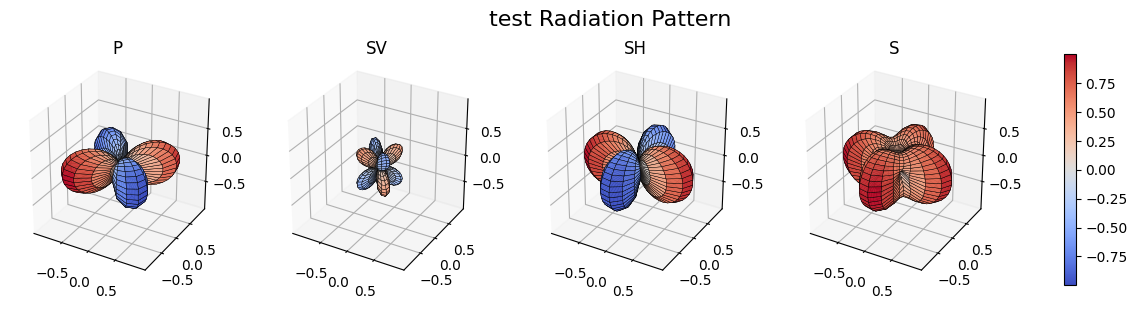

In [24]:
source.plot_radiation_pattern()

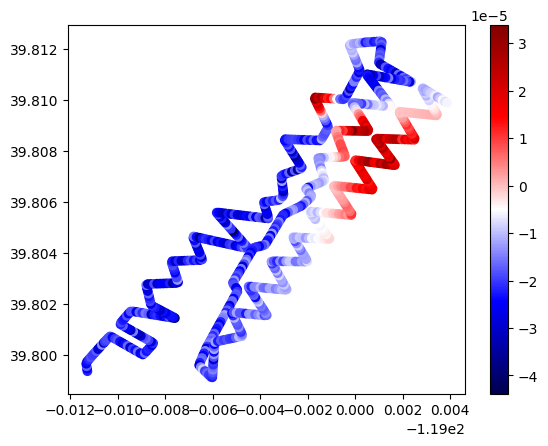

In [25]:
plt.scatter(df['lon'].values, df['lat'].values, c = result_container['P'], cmap = 'seismic')
plt.colorbar()

# Some plot to look at the data 

Optical distance vs amplitude for each wavetype 

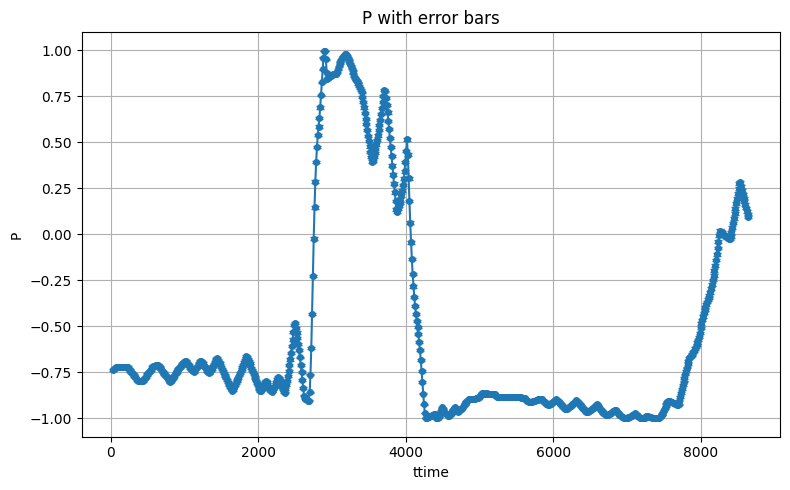

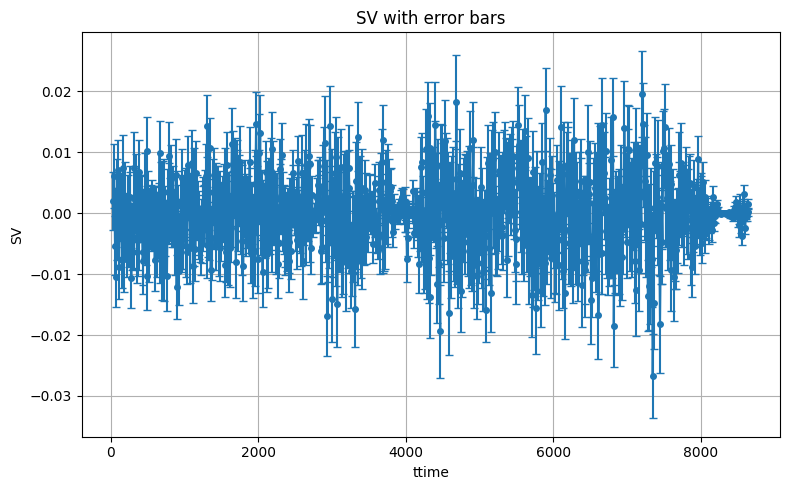

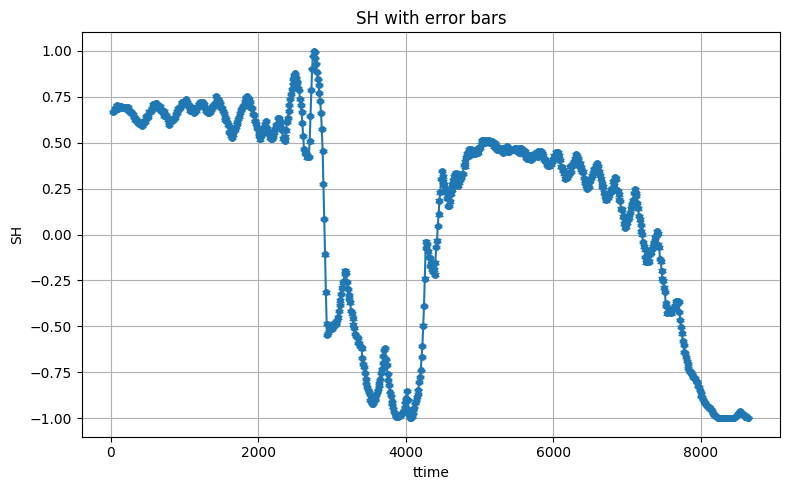

In [13]:

# Columns to plot: (value, error)
pairs = [
    ("P", "error_P"),
    ("SV", "error_SV"),
    ("SH", "error_SH"),
]

# x-axis
x = df.index

for value_col, error_col in pairs:
    plt.figure(figsize=(8, 5))

    plt.errorbar(
        x,
        result_container[value_col],
        yerr=result_container[error_col],
        fmt="o",
        markersize=4,
        capsize=3,
        linestyle="-"
    )

    plt.xlabel("ttime")
    plt.ylabel(value_col)
    plt.title(f"{value_col} with error bars")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

3D array geometry with amplitude of 1 wavetype 

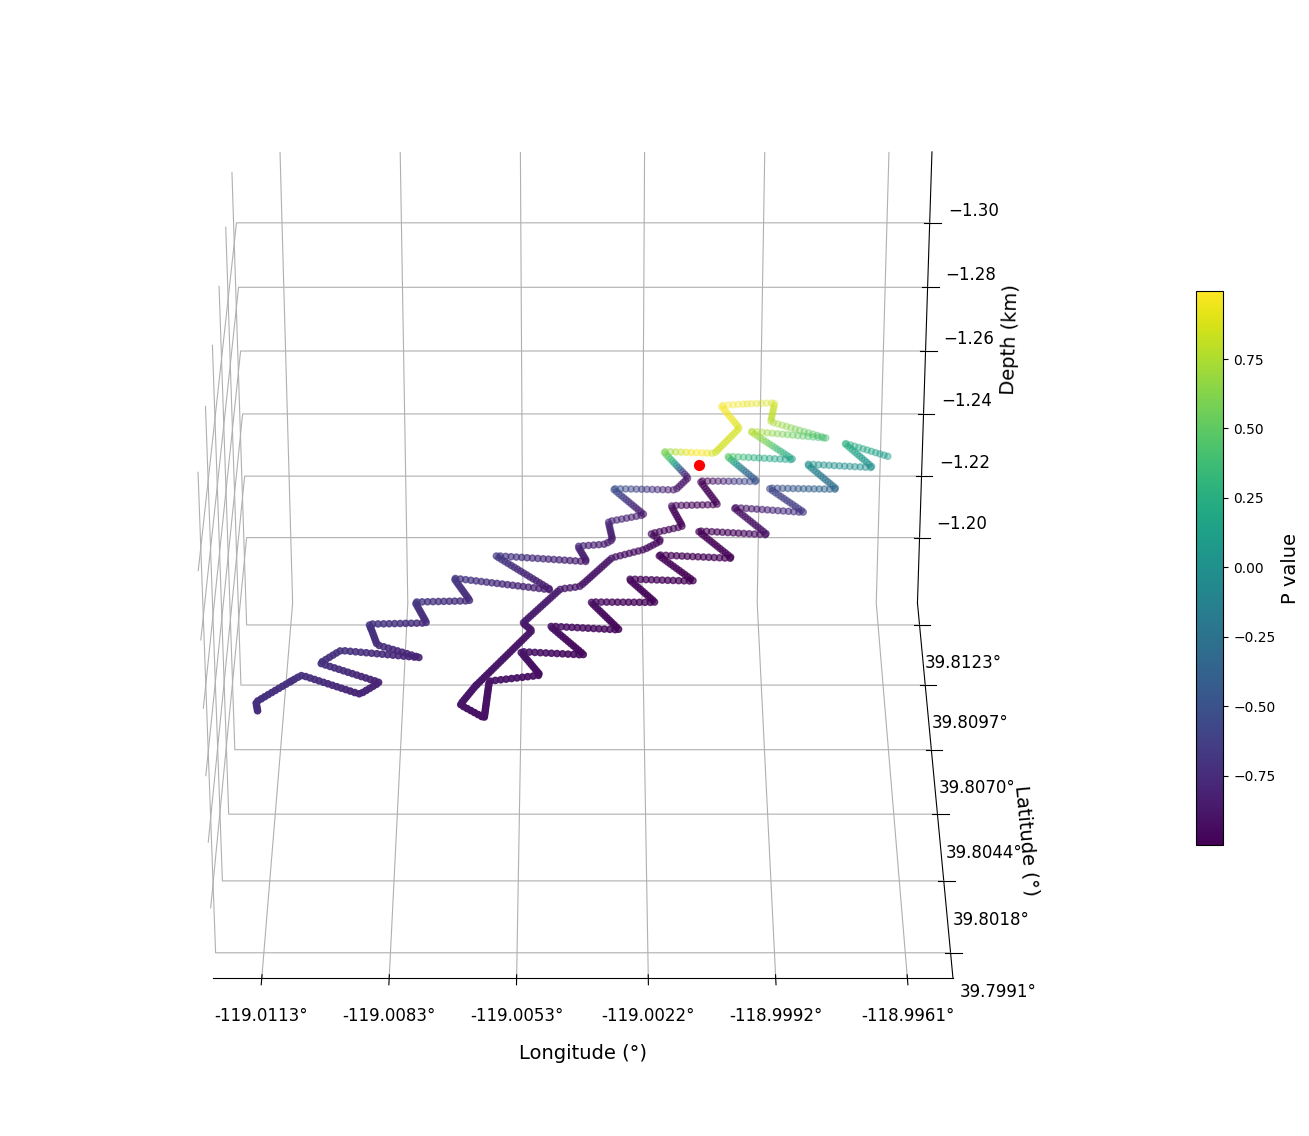

In [14]:
Phase_to_plot = 'P'

fig = plt.figure(figsize=(18, 18))
ax1 = fig.add_subplot(projection='3d')

# Save scatter object
sc = ax1.scatter(
    df['lon'].values,
    df['lat'].values,
    df['depth'].values,
    c=result_container[Phase_to_plot].values,
    cmap='viridis'
)

# Add colorbar
cbar = plt.colorbar(sc, ax=ax1, pad=0.05, shrink=0.4)
cbar.set_label(f"{Phase_to_plot} value", fontsize=14)

# Axis view & limits
ax1.view_init(elev=30, azim=-90)

# Labels
ax1.set_xlabel('Longitude (°)')
ax1.set_ylabel('Latitude (°)')
ax1.set_zlabel('Depth (km)')

# Custom ticks
lon_min, lon_max = df['lon'].min(), df['lon'].max()
lat_min, lat_max = df['lat'].min(), df['lat'].max()

lon_ticks = np.round(np.linspace(lon_min, lon_max, 6), 4)
lat_ticks = np.round(np.linspace(lat_min, lat_max, 6), 4)

ax1.set_xticks(lon_ticks)
ax1.set_yticks(lat_ticks)
ax1.set_xticklabels([f'{v:.4f}°' for v in lon_ticks])
ax1.set_yticklabels([f'{v:.4f}°' for v in lat_ticks])

ax1.tick_params(axis='x', labelsize=12, pad=6)
ax1.tick_params(axis='y', labelsize=12, pad=20)
ax1.tick_params(axis='z', labelsize=12, pad=20)

ax1.set_xlabel('Longitude (°)', fontsize=14, labelpad=15)
ax1.set_ylabel('Latitude (°)', fontsize=14, labelpad=35)
ax1.set_zlabel('Depth (km)', fontsize=14, labelpad=35)

ax1.scatter(
    source.location.values[1],
    source.location.values[0],
    source.location.values[2],
    s=50,
    c='r'
)

# Optional: transparent panes
ax1.xaxis.pane.fill = False
ax1.yaxis.pane.fill = False
ax1.zaxis.pane.fill = False

ax1.xaxis.pane.set_edgecolor('w')
ax1.yaxis.pane.set_edgecolor('w')
ax1.zaxis.pane.set_edgecolor('w')

ax1.invert_zaxis()

plt.show()